In [3]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [4]:
project_root = Path.cwd().parent

train_path = project_root / "data" / "raw" / "UNSW_NB15_training-set.csv"
test_path = project_root / "data" / "raw" / "UNSW_NB15_testing-set.csv"

print("Project root:", project_root)
print("Training file exists:", train_path.exists())
print("Testing file exists:", test_path.exists())

Project root: d:\PROGRAMMING\NetGuard AI\netguard_ai
Training file exists: True
Testing file exists: True


In [5]:
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

In [13]:
print(train_df.head())

   id       dur proto service state  spkts  dpkts  sbytes  dbytes       rate  \
0   1  0.121478   tcp       -   FIN      6      4     258     172  74.087490   
1   2  0.649902   tcp       -   FIN     14     38     734   42014  78.473372   
2   3  1.623129   tcp       -   FIN      8     16     364   13186  14.170161   
3   4  1.681642   tcp     ftp   FIN     12     12     628     770  13.677108   
4   5  0.449454   tcp       -   FIN     10      6     534     268  33.373826   

   ...  ct_dst_sport_ltm  ct_dst_src_ltm  is_ftp_login  ct_ftp_cmd  \
0  ...                 1               1             0           0   
1  ...                 1               2             0           0   
2  ...                 1               3             0           0   
3  ...                 1               3             1           1   
4  ...                 1              40             0           0   

   ct_flw_http_mthd  ct_src_ltm  ct_srv_dst  is_sm_ips_ports  attack_cat  \
0                 0   

In [6]:
print("Training shape: ",train_df.shape)
print("Testing shape: ", test_df.shape)

Training shape:  (175341, 45)
Testing shape:  (82332, 45)


In [7]:
print(train_df.columns.tolist())

['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


Missing Value Check

In [8]:
missing_values = train_df.isnull().sum()
missing_values = missing_values[missing_values > 0]

print(missing_values)

Series([], dtype: int64)


In [9]:
print("Binary label counts:")
print(train_df["label"].value_counts())

print("\nAttack category counts:")
print(train_df["attack_cat"].value_counts())

Binary label counts:
label
1    119341
0     56000
Name: count, dtype: int64

Attack category counts:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


Duplicate Values Cheeck

In [10]:
duplicate_count = train_df.duplicated().sum()
print("Duplicate training records:", duplicate_count)

Duplicate training records: 0


In [19]:
duplicate_without_id = train_df.drop(columns="id").duplicated().sum()

print("Duplicates excluding id:", duplicate_without_id)

Duplicates excluding id: 67601


In [22]:
duplicate_count = train_df.drop(columns="id").duplicated().sum()
duplicate_percentage = duplicate_count / len(train_df) * 100

print("Duplicate count:", duplicate_count)
print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

Duplicate count: 67601
Duplicate percentage: 38.55%


In [ ]:
duplicate_mask = train_df.drop(columns="id").duplicated(keep="first")

duplicate_class_counts = (
    train_df.loc[duplicate_mask, "attack_cat"]
    .value_counts()
)

print(duplicate_class_counts)

attack_cat
Generic           35819
Exploits          13549
DoS                8458
Normal             4110
Reconnaissance     2969
Fuzzers            2034
Analysis            406
Backdoor            211
Shellcode            42
Worms                 3
Name: count, dtype: int64


In [24]:
total_by_class = train_df["attack_cat"].value_counts()
duplicates_by_class = train_df.loc[duplicate_mask, "attack_cat"].value_counts()

duplicate_summary = pd.DataFrame({
    "total_records": total_by_class,
    "duplicate_records": duplicates_by_class
}).fillna(0)

duplicate_summary["duplicate_percentage"] = (
    duplicate_summary["duplicate_records"]
    / duplicate_summary["total_records"]
    * 100
).round(2)

duplicate_summary.sort_values(
    "duplicate_percentage",
    ascending=False
)

,total_records,duplicate_records,duplicate_percentage
attack_cat,,,
Generic,40000,35819,89.55
DoS,12264,8458,68.97
Exploits,33393,13549,40.57
Reconnaissance,10491,2969,28.30
Analysis,2000,406,20.30
Backdoor,1746,211,12.08
Fuzzers,18184,2034,11.19
Normal,56000,4110,7.34
Shellcode,1133,42,3.71


Binary Percentage and Charts

In [11]:
binary_percentage = (
    train_df["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(binary_percentage)

label
1    68.06
0    31.94
Name: proportion, dtype: float64


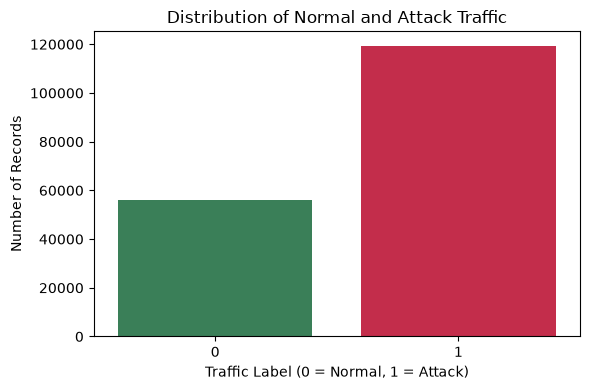

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=train_df,
    x="label",
    hue="label",
    palette=["#2E8B57","#DC143C"],
    legend=False
)
plt.title("Distribution of Normal and Attack Traffic")
plt.xlabel("Traffic Label (0 = Normal, 1 = Attack)")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.savefig(
    figures_path / "binary_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

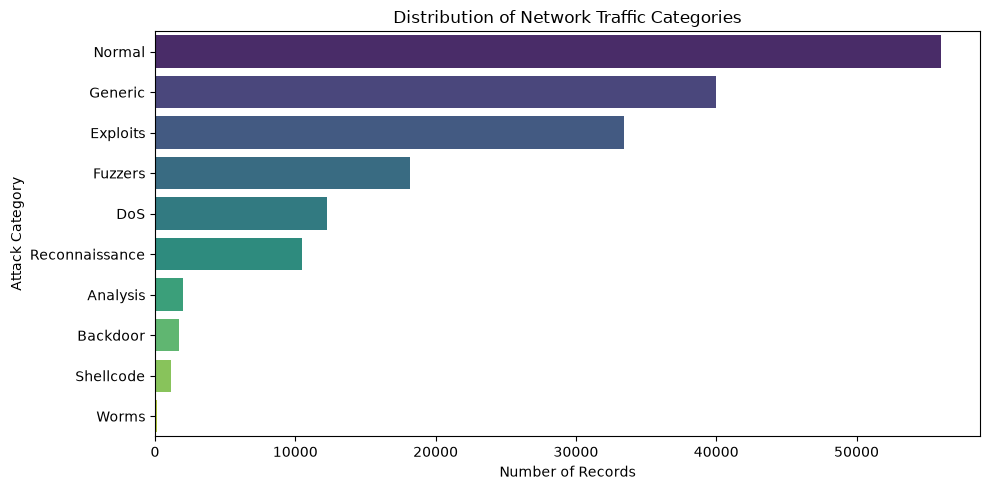

In [18]:
attack_counts = train_df["attack_cat"].value_counts()

plt.figure(figsize=(10, 5))

sns.barplot(
    x=attack_counts.values,
    y=attack_counts.index,
    hue=attack_counts.index,
    palette="viridis",
    legend=False
)

plt.title("Distribution of Network Traffic Categories")
plt.xlabel("Number of Records")
plt.ylabel("Attack Category")
plt.tight_layout()
plt.savefig(
    figures_path / "attack_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [16]:
figures_path = project_root / "reports" / "figures"
figures_path.mkdir(parents=True, exist_ok=True)

Categorical features understanding


In [25]:
categorical_columns = [
    column
    for column in train_df.columns
    if pd.api.types.is_string_dtype(train_df[column])
]

numerical_columns = [
    column
    for column in train_df.columns
    if pd.api.types.is_numeric_dtype(train_df[column])
]

print("Categorical columns:", categorical_columns)
print("Numerical column count:", len(numerical_columns))

Categorical columns: ['proto', 'service', 'state', 'attack_cat']
Numerical column count: 41


In [21]:
for column in ["proto", "service", "state"]:
    print(f"\n{column}:")
    print("Unique count:", train_df[column].nunique())
    print(train_df[column].value_counts().head(10))


proto:
Unique count: 133
proto
tcp       79946
udp       63283
unas      12084
arp        2859
ospf       2595
sctp       1150
any         300
gre         225
sun-nd      201
swipe       201
Name: count, dtype: int64

service:
Unique count: 13
service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp           94
snmp           80
Name: count, dtype: int64

state:
Unique count: 9
state
INT    82275
FIN    77825
CON    13152
REQ     1991
RST       83
ECO       12
PAR        1
URN        1
no         1
Name: count, dtype: int64


Categorical-feature interpretation

In [26]:
feature_columns = train_df.columns.drop(
    ["id", "label", "attack_cat"]
).tolist()

print("Input feature count:", len(feature_columns))

Input feature count: 42


In [27]:
feature_hash = pd.util.hash_pandas_object(
    train_df[feature_columns],
    index=False
)

label_check = pd.DataFrame({
    "feature_hash": feature_hash,
    "label": train_df["label"],
    "attack_cat": train_df["attack_cat"]
})

In [28]:
binary_conflicts = (
    label_check.groupby("feature_hash")["label"]
    .nunique()
    .gt(1)
    .sum()
)

print("Feature patterns with conflicting binary labels:", binary_conflicts)

Feature patterns with conflicting binary labels: 229


In [29]:
multiclass_conflicts = (
    label_check.groupby("feature_hash")["attack_cat"]
    .nunique()
    .gt(1)
    .sum()
)

print(
    "Feature patterns with conflicting attack categories:",
    multiclass_conflicts
)

Feature patterns with conflicting attack categories: 1772


In [30]:
train_hashes = set(feature_hash)

test_feature_hash = pd.util.hash_pandas_object(
    test_df[feature_columns],
    index=False
)

test_overlap_count = test_feature_hash.isin(train_hashes).sum()
test_overlap_percentage = test_overlap_count / len(test_df) * 100

print("Test records matching training feature patterns:", test_overlap_count)
print(f"Train-test overlap percentage: {test_overlap_percentage:.2f}%")

Test records matching training feature patterns: 8541
Train-test overlap percentage: 10.37%


In [31]:
binary_conflict_hashes = (
    label_check.groupby("feature_hash")["label"]
    .nunique()
)

binary_conflict_hashes = binary_conflict_hashes[
    binary_conflict_hashes > 1
].index

binary_conflict_rows = label_check[
    label_check["feature_hash"].isin(binary_conflict_hashes)
]

print("Binary conflict groups:", len(binary_conflict_hashes))
print("Rows affected by binary conflicts:", len(binary_conflict_rows))

print("\nLabels inside conflicting patterns:")
print(binary_conflict_rows["label"].value_counts())

Binary conflict groups: 229
Rows affected by binary conflicts: 940

Labels inside conflicting patterns:
label
1    544
0    396
Name: count, dtype: int64


In [32]:
multiclass_conflict_hashes = (
    label_check.groupby("feature_hash")["attack_cat"]
    .nunique()
)

multiclass_conflict_hashes = multiclass_conflict_hashes[
    multiclass_conflict_hashes > 1
].index

multiclass_conflict_rows = label_check[
    label_check["feature_hash"].isin(multiclass_conflict_hashes)
]

print("Multiclass conflict groups:", len(multiclass_conflict_hashes))
print("Rows affected by multiclass conflicts:", len(multiclass_conflict_rows))

print("\nCategories inside conflicting patterns:")
print(multiclass_conflict_rows["attack_cat"].value_counts())

Multiclass conflict groups: 1772
Rows affected by multiclass conflicts: 30528

Categories inside conflicting patterns:
attack_cat
Exploits          13299
DoS                9746
Fuzzers            2078
Reconnaissance     1889
Analysis           1441
Backdoor           1340
Normal              396
Generic             319
Worms                13
Shellcode             7
Name: count, dtype: int64


In [33]:
binary_conflict_percentage = (
    len(binary_conflict_rows) / len(train_df) * 100
)

multiclass_conflict_percentage = (
    len(multiclass_conflict_rows) / len(train_df) * 100
)

print(f"Rows affected by binary conflicts: {binary_conflict_percentage:.2f}%")
print(f"Rows affected by multiclass conflicts: {multiclass_conflict_percentage:.2f}%")

Rows affected by binary conflicts: 0.54%
Rows affected by multiclass conflicts: 17.41%


In [34]:
example_hash = binary_conflict_hashes[0]

example_indices = label_check.index[
    label_check["feature_hash"] == example_hash
]

train_df.loc[
    example_indices,
    ["proto", "service", "state", "label", "attack_cat"]
]

,proto,service,state,label,attack_cat
47563,udp,-,INT,0,Normal
48339,udp,-,INT,1,Fuzzers
51236,udp,-,INT,1,Fuzzers
89153,udp,-,INT,1,Fuzzers
98766,udp,-,INT,1,Fuzzers
